# Exploratory Analysis of a Patient Health Dataset
This notebook demonstrates data loading, inspection, cleaning, and a simple exploratory analysis in Python using a sample patient health dataset.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

In [61]:
# Load the data
df = pd.read_csv("../data/health.csv")

## Initial inspection

In [42]:
df.head()

,Patient_ID,Age,Gender,Blood_Type,Height_cm,Weight_kg,BMI,Temperature_C,Heart_Rate_bpm,Blood_Pressure_mmHg
0,P001,45,Male,O,175,70,22.86,36.6,72,120/80
1,P002,32,Female,A,160,55,21.48,37.1,75,118/75
2,P003,50,Female,B,165,80,29.38,36.8,80,130/85
3,P004,25,Male,AB,180,90,27.78,36.5,68,125/82
4,P005,60,Male,A,170,65,22.49,37.0,85,140/90


In [39]:
df.shape

(5, 12)

In [34]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Blood_Type', 'Height_cm', 'Weight_kg',
       'BMI', 'Temperature_C', 'Heart_Rate_bpm', 'Blood_Pressure_mmHg'],
      dtype='str')

In [43]:
df.isnull().sum()

Patient_ID             0
Age                    0
Gender                 0
Blood_Type             0
Height_cm              0
Weight_kg              0
BMI                    0
Temperature_C          0
Heart_Rate_bpm         0
Blood_Pressure_mmHg    0
dtype: int64

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           5 non-null      str    
 1   Age                  5 non-null      int64  
 2   Gender               5 non-null      str    
 3   Blood_Type           5 non-null      str    
 4   Height_cm            5 non-null      int64  
 5   Weight_kg            5 non-null      int64  
 6   BMI                  5 non-null      float64
 7   Temperature_C        5 non-null      float64
 8   Heart_Rate_bpm       5 non-null      int64  
 9   Blood_Pressure_mmHg  5 non-null      str    
dtypes: float64(2), int64(4), str(4)
memory usage: 532.0 bytes


In [59]:
df.describe()

,Age,Height_cm,Weight_kg,BMI,Temperature_C,Heart_Rate_bpm,Systolic_BP,Diastolic_BP
count,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000
mean,42.40000,170.000000,72.000000,24.798000,36.800000,76.000000,126.600000,82.40000
std,14.01071,7.905694,13.509256,3.534787,0.254951,6.670832,8.820431,5.59464
min,25.00000,160.000000,55.000000,21.480000,36.500000,68.000000,118.000000,75.00000
25%,32.00000,165.000000,65.000000,22.490000,36.600000,72.000000,120.000000,80.00000
50%,45.00000,170.000000,70.000000,22.860000,36.800000,75.000000,125.000000,82.00000
75%,50.00000,175.000000,80.000000,27.780000,37.000000,80.000000,130.000000,85.00000
max,60.00000,180.000000,90.000000,29.380000,37.100000,85.000000,140.000000,90.00000


## Exploratory analysis
First, let us provide a histogram to describe the age distribution of the patients in our dataset.

In [56]:
age_bins = [20, 30, 40, 50, 60]
df["Age_Group"] = pd.cut(df["Age"], bins=age_bins)

df["Age_Group"].value_counts().sort_index()

Age_Group
(20, 30]    1
(30, 40]    1
(40, 50]    2
(50, 60]    1
Name: count, dtype: int64

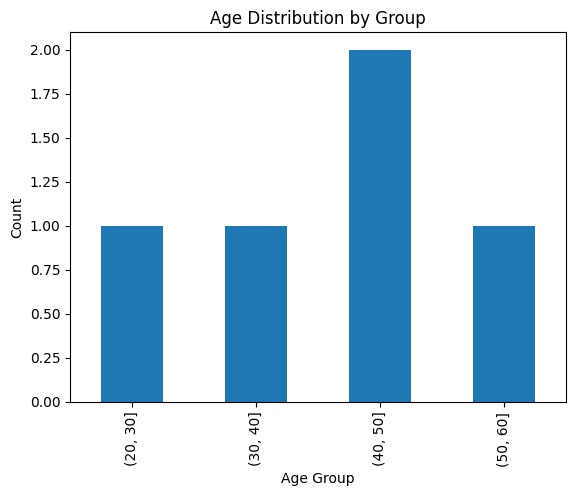

In [58]:
df["Age_Group"].value_counts().sort_index().plot.bar()
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.title("Age Distribution by Group")
plt.show()

Now let us explore a possible relation between gender and blood pressure in the data.

In [45]:
# Data cleaning: Splitting the blood pressure data into separate values for systolic and diastolic
bp_split = df["Blood_Pressure_mmHg"].str.split("/", expand=True)
df["Systolic_BP"] = bp_split[0].astype(int)
df["Diastolic_BP"] = bp_split[1].astype(int)
df[["Blood_Pressure_mmHg", "Systolic_BP", "Diastolic_BP"]].head()

,Blood_Pressure_mmHg,Systolic_BP,Diastolic_BP
0,120/80,120,80
1,118/75,118,75
2,130/85,130,85
3,125/82,125,82
4,140/90,140,90


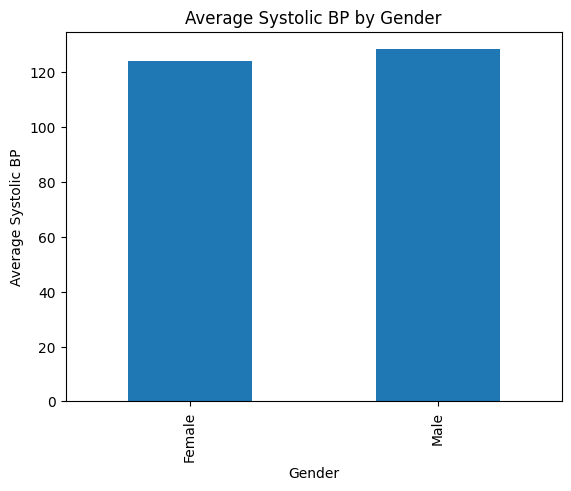

In [37]:
# Find and plot average systolic blood pressure by gender
df.groupby("Gender")["Systolic_BP"].mean().plot.bar()
plt.ylabel("Average Systolic BP")
plt.title("Average Systolic BP by Gender")
plt.show()

Finally, let us consider whether there exists a noticeable correlation between BMI and heart rate in the data.

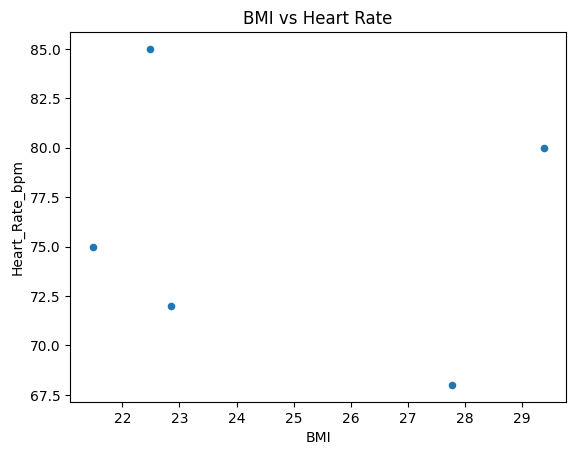

In [38]:
# Produces a scatter plot for BMI vs heart rate
df.plot.scatter(x="BMI", y="Heart_Rate_bpm")
plt.title("BMI vs Heart Rate")
plt.show()

## Findings
The average systolic blood pressure was slightly higher for males than females.

We found no strong correlation between BMI and heart rate in the given dataset.